# Introduction
Terminology used in Binary Search:

- Target - the value that you are searching for
- Index - the current location that you are searching
- Left, Right - the indices from which we use to maintain our search Space
- Mid - the index that we use to apply a condition to determine if we should search left or right

# Basic Binary Search
```python
class Solution(object):
    def search(self, nums, target):
        """
        :type nums: List[int]
        :type target: int
        :rtype: int
        """ 
        l, r = 0, len(nums) - 1
        
        while l <= r:
            mid = (l+r)//2
            if nums[mid] == target:
                return mid
            elif nums[mid] > target:
                r = mid - 1
            else:
                l = mid + 1
                
        return -1
```        


## Search in Rotated Sorted Array
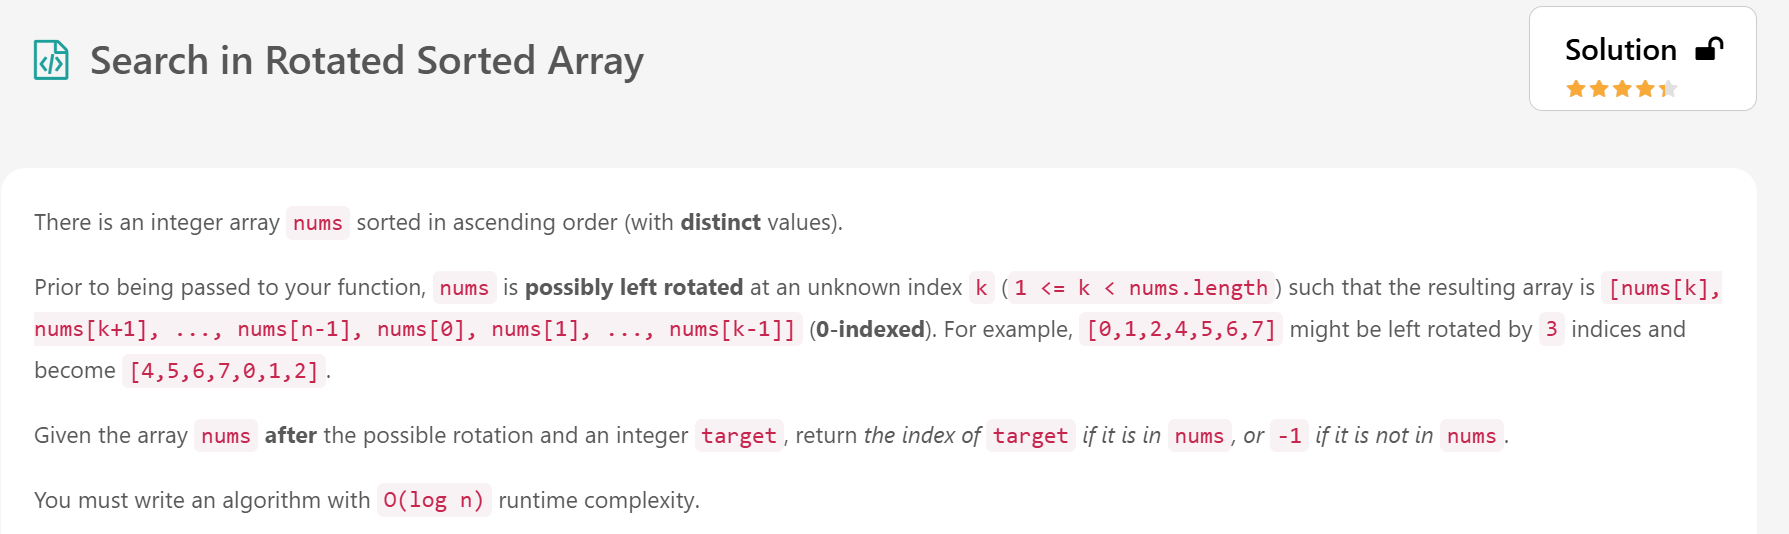
```python
class Solution(object):
    def search(self, nums, target):
        """
        :type nums: List[int]
        :type target: int
        :rtype: int
        """
        l, r = 0, len(nums) - 1
        
        while l <= r:
            mid = (l+r) // 2
            if nums[mid] > nums[-1]:
                l = mid + 1
            else:
                r = mid - 1
                
        pivot = l
        
        def binarySearch(l,r,target):
            while l <= r:
                mid = (l+r)//2
                if nums[mid] == target:
                    return mid
                elif nums[mid] < target:
                    l = mid + 1
                else:
                    r = mid - 1
            return -1
        
        ans = binarySearch(0,pivot-1,target)
        
        if ans == -1:
            return binarySearch(pivot,len(nums)-1,target)
        else:
            return ans
```

## Find Peak Element
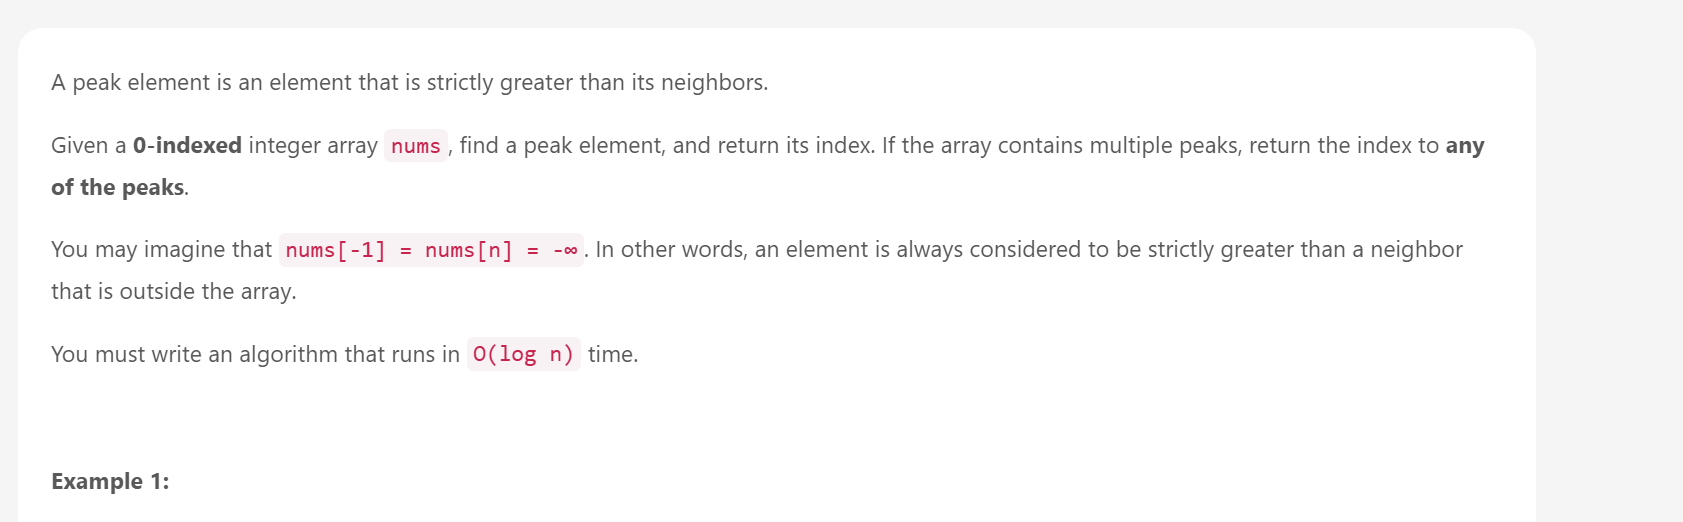
```python
class Solution(object):
    def findPeakElement(self, nums):
        """
        :type nums: List[int]
        :rtype: int
        """
        l, r = 0, len(nums) - 1
        
        while l < r:
            mid = (l+r) // 2
            if nums[mid] > nums[mid+1]:
                r = mid
            else:
                l = mid + 1
                
        return l
```

# Template

## Template 1 (Standard Binary Search)
适合：数组中找 target 是否存在，存在就返回下标，不存在返回 -1。
```python
def binary_search_template_1(nums, target):
    left, right = 0, len(nums) - 1

    while left <= right:
        mid = left + (right - left) // 2

        if nums[mid] == target:
            return mid
        elif nums[mid] < target:
            left = mid + 1
        else:
            right = mid - 1

    return -1
```

## Template 2 (找边界，最后剩下 2 个候选)
适合：找第一个满足条件的位置，比如：
第一个 >= target 的位置
第一个 > target 的位置
第一个 True 的位置
```python
def lower_bound(nums, target):
    """
    返回第一个 >= target 的位置
    如果所有元素都 < target，返回 len(nums)
    """
    left, right = 0, len(nums)

    while left < right:
        mid = left + (right - left) // 2

        if nums[mid] < target:
            left = mid + 1
        else:
            right = mid

    return left
```

## Template 3 (Finding the Rightmost Occurrence)
适合：有些题目中，你希望最后保留两个候选，再做判断。比如查找最近值、山峰、旋转数组边界等。
```python
def binary_search_template_3(nums, target):
    left, right = 0, len(nums) - 1

    while left + 1 < right:
        mid = left + (right - left) // 2

        if nums[mid] < target:
            left = mid
        else:
            right = mid

    # post-processing
    if nums[left] == target:
        return left
    if nums[right] == target:
        return right

    return -1
```

# Application

##  Find Minimum in Rotated Sorted Array
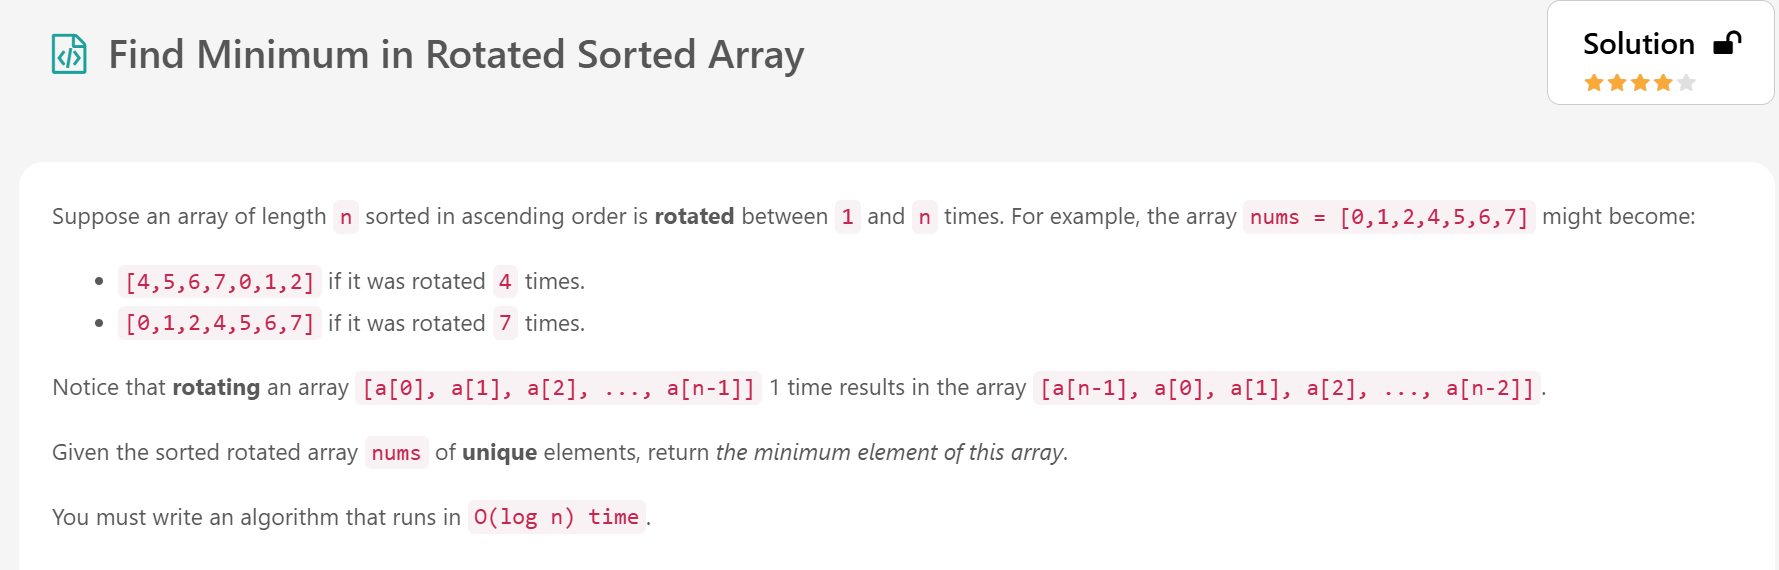

```python
class Solution(object):
    def findMin(self, nums):
        """
        :type nums: List[int]
        :rtype: int
        """
        l, r = 0, len(nums) - 1
        while l < r:
            mid = (l+r)//2
            if nums[mid] > nums[-1]:
                l = mid + 1
            else:
                r = mid
                
        return nums[l]
```

## Find Minimum in Rotated Sorted Array II
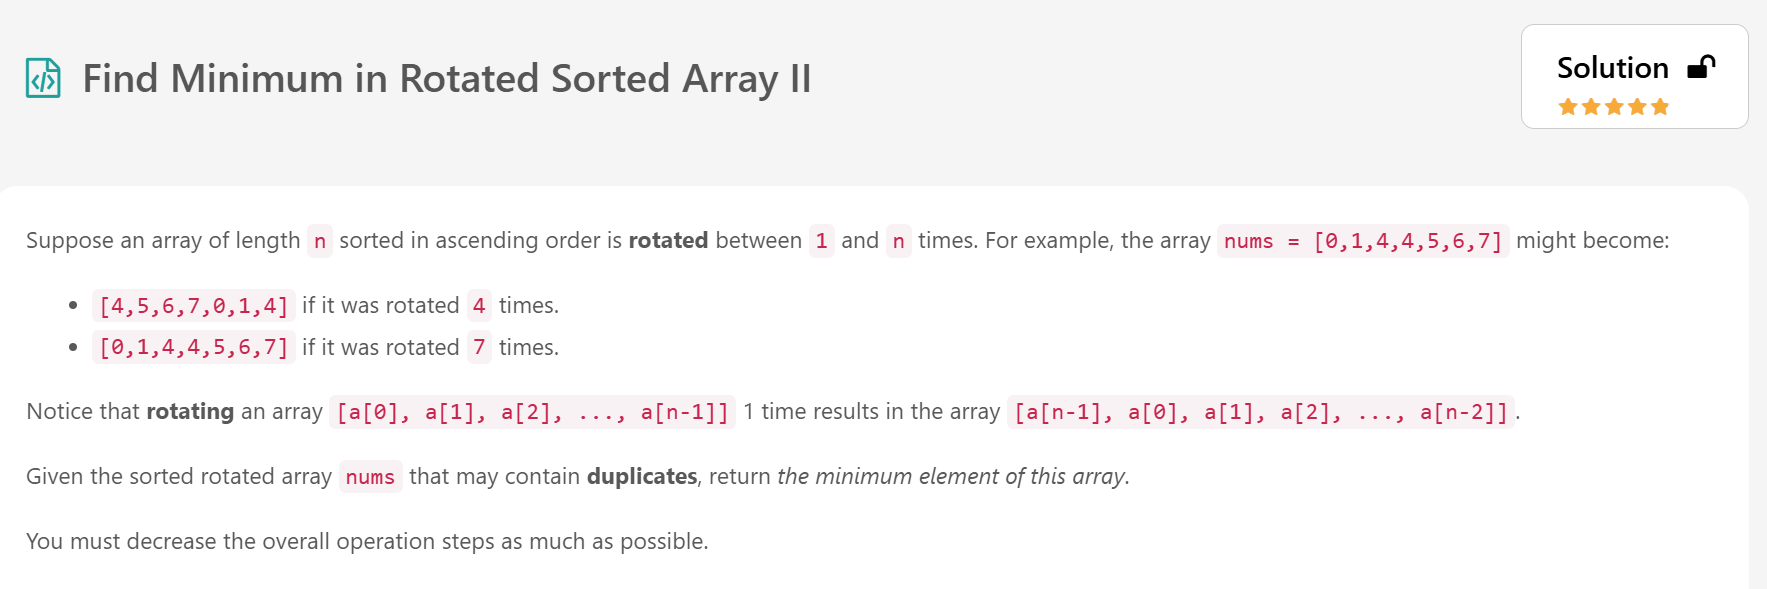
```python
class Solution(object):
    def findMin(self, nums):
        """
        :type nums: List[int]
        :rtype: int
        """
        l, r = 0, len(nums) - 1
        while l < r:
            mid = (l+r) //2
            if nums[mid] > nums[r]:
            # mid 在左侧较大段，最小值一定在 mid 右边
                l = mid + 1
            
            elif nums[mid] < nums[r]:
            # mid 在右侧较小段，最小值可能就是 mid
                r = mid
                
            else:
            # nums[mid] == nums[r]
            # 无法判断最小值在哪边，只能安全地缩小右边界
                r-= 1
                
        return nums[l]